Dataset Exploration

1.Load the dataset into a Pandas dataframe and display the first 10 rows.

In [1]:
import pandas as pd

# Load the dataset (assuming it's an Excel file named 'nba_stats.xlsx')
nba_df = pd.read_excel('nba_stats.xlsx')

# Display the first 10 rows
print(nba_df.head(10))


                 Player Pos  Age   Tm   G  GS    MP   FG   FGA    FG%  ...  \
0  Kareem Abdul-Jabbar*   C   41  LAL  74  74  1695  313   659  0.475  ...   
1            Mark Acres   C   26  BOS  62   0   632   55   114  0.482  ...   
2         Michael Adams  PG   26  DEN  77  77  2787  468  1082  0.433  ...   
3          Mark Aguirre  SF   29  TOT  80  76  2597  586  1270  0.461  ...   
4          Mark Aguirre  SF   29  DAL  44  44  1529  373   829  0.450  ...   
5          Mark Aguirre  SF   29  DET  36  32  1068  213   441  0.483  ...   
6           Danny Ainge  PG   29  TOT  73  54  2377  480  1051  0.457  ...   
7           Danny Ainge  PG   29  BOS  45  28  1349  271   589  0.460  ...   
8           Danny Ainge  PG   29  SAC  28  26  1028  209   462  0.452  ...   
9           Mark Alarie  PF   25  WSB  74   5  1141  206   431  0.478  ...   

    FT  FTA  ORB  DRB  AST  STL  BLK   PF   PTS   YEAR  
0  122  165  103  231   74   38   85  196   748  88-89  
1   26   48   59   87   19 

2.Display the shape of the dataset (i.e. number of rows and columns)

In [2]:
print(f"Number of rows: {nba_df.shape[0]}")
print(f"Number of columns: {nba_df.shape[1]}")
print("\nShape of the DataFrame:")
print(nba_df.shape)

Number of rows: 5459
Number of columns: 26

Shape of the DataFrame:
(5459, 26)


3.Identify the data types of each column and check for any missing values (number of missing values in each column).

In [3]:
print("\nData types of each column:")
print(nba_df.dtypes)
print("\nNumber of missing values in each column:")
print(nba_df.isnull().sum())


Data types of each column:
Player     object
Pos        object
Age         int64
Tm         object
G           int64
GS          int64
MP          int64
FG          int64
FGA         int64
FG%       float64
3P          int64
3PA         int64
3P%       float64
2P          int64
2PA         int64
2P%       float64
FT          int64
FTA         int64
ORB         int64
DRB         int64
AST         int64
STL         int64
BLK         int64
PF          int64
PTS         int64
YEAR       object
dtype: object

Number of missing values in each column:
Player      0
Pos         0
Age         0
Tm          0
G           0
GS          0
MP          0
FG          0
FGA         0
FG%        25
3P          0
3PA         0
3P%       997
2P          0
2PA         0
2P%        32
FT          0
FTA         0
ORB         0
DRB         0
AST         0
STL         0
BLK         0
PF          0
PTS         0
YEAR        0
dtype: int64


4.For the entire dataset (in its current form), list how many players played for each team in the NBA.

In [4]:
print("\nNumber of players played for each team:")
print(nba_df['Tm'].value_counts())


Number of players played for each team:
Tm
TOT    372
GSW    217
CHH    206
SAS    204
LAC    202
PHI    200
DEN    198
WSB    198
SAC    197
DAL    195
BOS    194
MIL    193
NJN    190
ATL    189
DET    187
UTA    186
PHO    185
CLE    185
CHI    184
HOU    182
IND    176
NYK    176
MIA    176
LAL    175
ORL    174
SEA    173
MIN    173
POR    172
Name: count, dtype: int64


Data Cleaning and Preparation

1.Remove any duplicate rows in the dataset. Only keep the first of each duplicate row.

In [5]:
nba_df.drop_duplicates(inplace=True)

2.Rename the 'Tm' column to 'Team' and ‘MP’ column to 'Mins_Played'.

In [6]:
nba_df.rename(columns={'Tm': 'Team', 'MP': 'Mins_Played'}, inplace=True)

3.Remove any rows with ‘TOT’ in the Team column.

In [7]:
nba_df = nba_df[nba_df['Team'] != 'TOT']


4.Create a new column called ‘FT_PERCENT’ that shows the free throw percent of each player. Free throw percent is calculated by FT/FTA. Place the column after FTA.



In [8]:
# Calculate free throw percentage by dividing 'FT' by 'FTA'
nba_df['FT_PERCENT'] = nba_df['FT'] / nba_df['FTA']

# Reorder the columns to place 'FT_PERCENT' after 'FTA'
nba_df = nba_df[['Player', 'Pos', 'Age', 'Team', 'G', 'GS', 'Mins_Played', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'FT', 'FTA', 'FT_PERCENT', 'ORB', 'DRB', 'AST', 'STL', 'BLK', 'PF', 'PTS', 'YEAR']]








5.Create a new column called ‘TRB’ (Total Rebounds) that shows the sum of ORB and DRB. Place the column after DRB.

In [9]:
nba_df['TRB'] = nba_df['ORB'] + nba_df['DRB']  # Calculate total rebounds by summing 'ORB' and 'DRB'
 # Reorder the columns to place 'TRB' after 'DRB'
nba_df = nba_df[['Player', 'Pos', 'Age', 'Team', 'G', 'GS', 'Mins_Played', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'FT', 'FTA', 'FT_PERCENT', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'PF', 'PTS', 'YEAR']]
nba_df

,Player,Pos,Age,Team,G,GS,Mins_Played,FG,FGA,FG%,...,FT_PERCENT,ORB,DRB,TRB,AST,STL,BLK,PF,PTS,YEAR
0,Kareem Abdul-Jabbar*,C,41,LAL,74,74,1695,313,659,0.475,...,0.739394,103,231,334,74,38,85,196,748,88-89
1,Mark Acres,C,26,BOS,62,0,632,55,114,0.482,...,0.541667,59,87,146,19,19,6,94,137,88-89
2,Michael Adams,PG,26,DEN,77,77,2787,468,1082,0.433,...,0.819338,71,212,283,490,166,11,149,1424,88-89
4,Mark Aguirre,SF,29,DAL,44,44,1529,373,829,0.450,...,0.729508,90,145,235,189,29,29,128,953,88-89
5,Mark Aguirre,SF,29,DET,36,32,1068,213,441,0.483,...,0.738255,56,95,151,89,16,7,101,558,88-89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3173,David Wood,PF,30,GSW,78,13,1336,153,326,0.469,...,0.777778,83,158,241,65,28,13,217,428,94-95
3174,Randy Woods,PG,24,LAC,62,3,495,37,117,0.316,...,0.736842,10,34,44,134,41,0,87,124,94-95
3175,Haywoode Workman,PG,29,IND,69,14,1028,101,269,0.375,...,0.743243,21,90,111,194,59,5,115,292,94-95
3176,Sharone Wright,C,22,PHI,79,49,2044,361,776,0.465,...,0.645390,191,281,472,48,37,104,246,904,94-95


6.Convert 3P% and 2P% from decimal to a percentage. Display the value in the following format (ex: 45%)

In [10]:
nba_df['3P%'] = (nba_df['3P%'] * 100).astype(str) + '%'  # Convert '3P%' to a percentage string format
nba_df['2P%'] = (nba_df['2P%'] * 100).astype(str) + '%'  # Convert '2P%' to a percentage string format

Section 3: Data Analysis and Visualization

1.How many players scored more than 2,000 points in the year 92-93?

In [11]:
# 1. Count players who scored more than 2,000 points in the year 92-93
points_92_93 = nba_df[(nba_df['YEAR'] == '92-93') & (nba_df['PTS'] > 2000)]
print("\nNumber of players who scored more than 2,000 points in the year 92-93:", len(points_92_93))



Number of players who scored more than 2,000 points in the year 92-93: 4


2.Create a line plot that shows the frequency of the top 5 players for the most 3 Points (3P) made in the year 94-95.

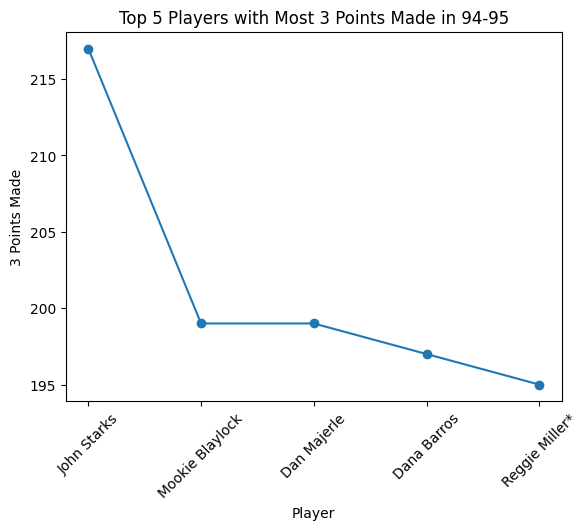

In [12]:
import matplotlib.pyplot as plt
top_5_3P_94_95 = nba_df[nba_df['YEAR'] == '94-95'].nlargest(5, '3P')
plt.plot(top_5_3P_94_95['Player'], top_5_3P_94_95['3P'], marker='o')
plt.xlabel('Player')
plt.ylabel('3 Points Made')
plt.title('Top 5 Players with Most 3 Points Made in 94-95')
plt.xticks(rotation=45)
plt.show()


3.What is the relationship between the player’s age and the number of points scored? The scatter plot should show the player's age on the x-axis, and the number of points scored on the y-axis.

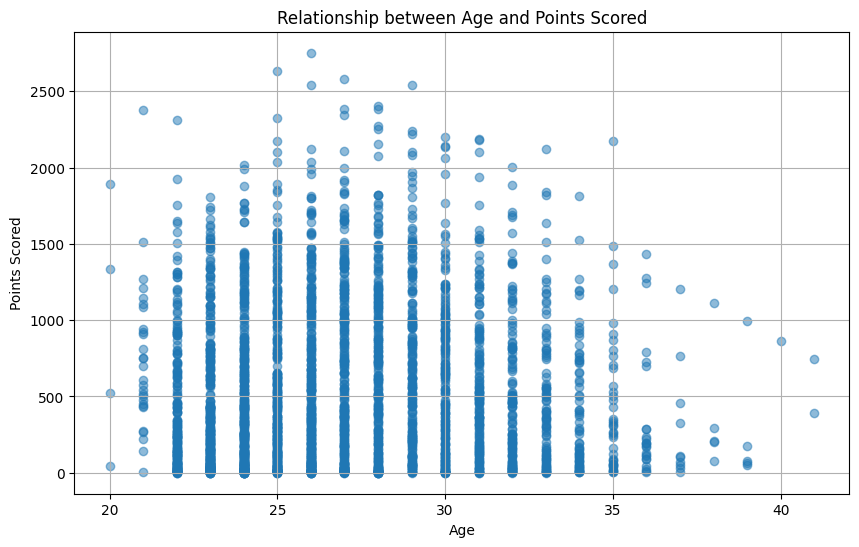

In [13]:
# 3. What is the relationship between the player’s age and the number of points scored? 
# The scatter plot should show the player's age on the x-axis, and the number of points scored on the y-axis.
plt.figure(figsize=(10, 6))
plt.scatter(nba_df['Age'], nba_df['PTS'], alpha=0.5)
plt.title('Relationship between Age and Points Scored')
plt.xlabel('Age')
plt.ylabel('Points Scored')
plt.grid(True)
plt.show()


4.Create a boxplot that show the number of points scored for each position in the year 90-91.

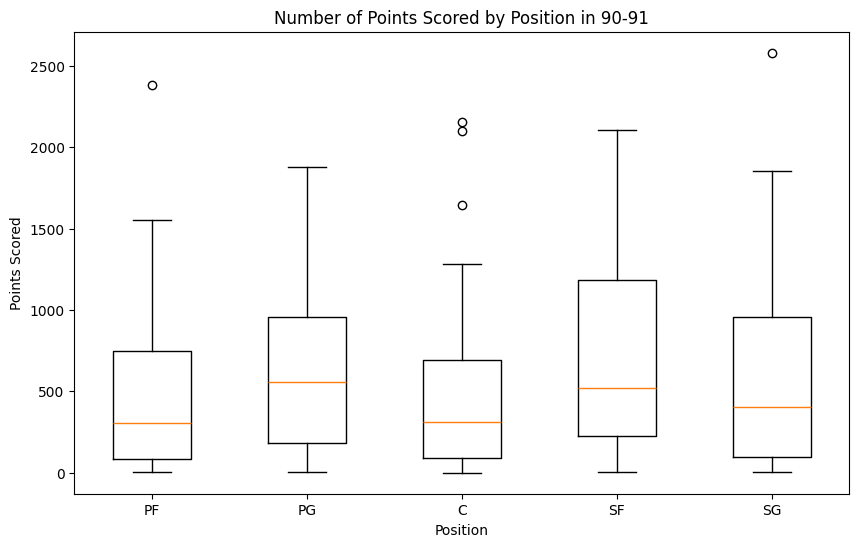

In [14]:
plt.figure(figsize=(10, 6))
nba_90_91 = nba_df[nba_df['YEAR'] == '90-91']
plt.boxplot([nba_90_91[nba_90_91['Pos'] == pos]['PTS'] for pos in nba_90_91['Pos'].unique()],
            labels=nba_90_91['Pos'].unique())
plt.title('Number of Points Scored by Position in 90-91')
plt.xlabel('Position')
plt.ylabel('Points Scored')
plt.show()

5.Create a bar chart that shows the total number of players by age in the year 90-91. 

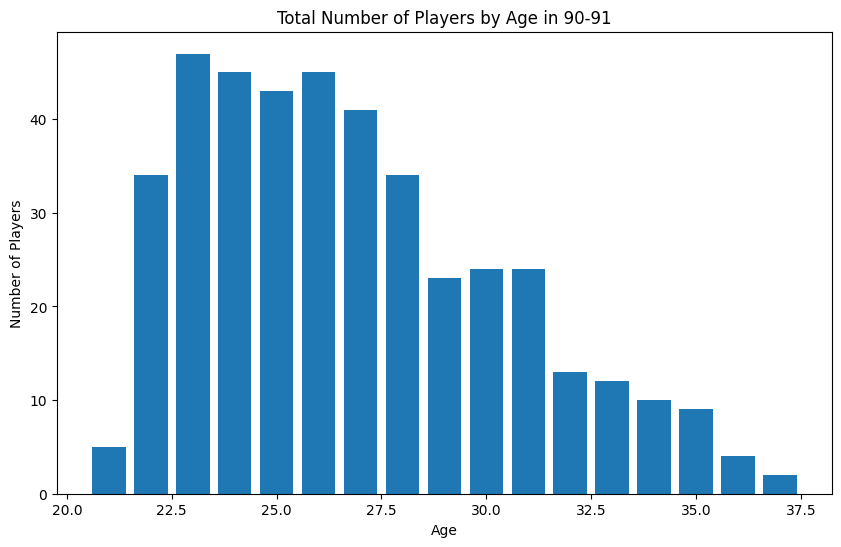

In [15]:
# 5. Create a bar chart that shows the total number of players by age in the year 90-91.
plt.figure(figsize=(10, 6))
players_by_age = nba_90_91['Age'].value_counts().sort_index()
plt.bar(players_by_age.index, players_by_age.values)
plt.title('Total Number of Players by Age in 90-91')
plt.xlabel('Age')
plt.ylabel('Number of Players')
plt.show()

6.Create a bar chart that counts the number of players at each position in the year 90-91.

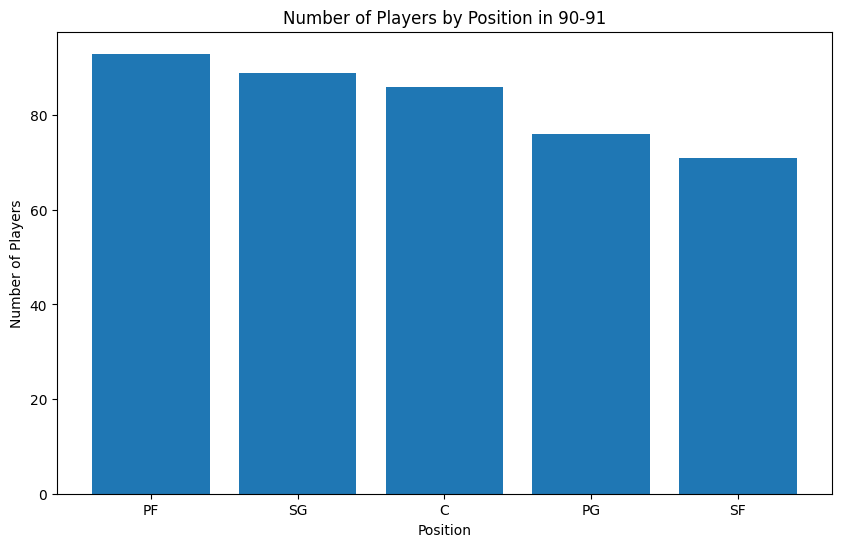

In [16]:
# 6. Create a bar chart that counts the number of players at each position in the year 90-91.
plt.figure(figsize=(10, 6))
players_by_position = nba_90_91['Pos'].value_counts()
plt.bar(players_by_position.index, players_by_position.values)
plt.title('Number of Players by Position in 90-91')
plt.xlabel('Position')
plt.ylabel('Number of Players')
plt.show()

7.Who lead the NBA in Total Rebounds in the year 91-92?

In [17]:
rebounds_91_92 = nba_df[nba_df['YEAR'] == '91-92']
top_rebounder = rebounds_91_92.loc[rebounds_91_92['TRB'].idxmax(), 'Player']
print(top_rebounder)

Dennis Rodman*


8.Who had the highest assist average in the year 93-94? What was the assist average for that player?

In [18]:
top_assist_avg_93_94 = nba_df[nba_df['YEAR'] == '93-94'].nlargest(1, 'AST')
print("\nPlayer with the highest assist average in 93-94:", top_assist_avg_93_94['Player'].values[0])
print("Assist average for that player:", top_assist_avg_93_94['AST'].values[0])


Player with the highest assist average in 93-94: John Stockton*
Assist average for that player: 1031
